In [74]:
# 12 January 2026
# Zachary Katz
# zachary_katz@mines.edu

"""
Load offset video KRT2 radar over Subglacial Lake Cheongsuk [David Glacier]
Hilbert transform to complex space and compute doppler spectra
Pick width and maximum frequency and plot in map view
"""

import os

import numpy as np
import scipy
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from skimage import feature, filters
from skimage.filters import sato


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs


import segyio
import shapefile
import shapely
import xarray as xr

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load utig netcdf files
utig_path = './_data/UTG_Complex'
file_paths = [os.path.join(utig_path, f) for f in os.listdir(utig_path) if f.endswith('.nc')]

utig_radargrams = []
for f in file_paths[:]:
    utig_radargram = xr.open_dataset(f)
    utig_radargrams.append(utig_radargram)


/tmp/ipykernel_20837/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  utig_radargram = xr.open_dataset(f)
/tmp/ipykernel_20837/842517954.py:7: FutureWarning: In a future version, xarray will not decode the variable 'fast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To con

In [3]:
utig_radargrams.sort(key=lambda x: x.transect_id)
utig_radargrams[0]

<xarray.Dataset> Size: 899MB
Dimensions:    (distance: 23382, fast_time: 3200)
Coordinates:
  * distance   (distance) float64 187kB 0.0 1.0 2.0 ... 2.338e+04 2.338e+04
  * fast_time  (fast_time) timedelta64[ns] 26kB 00:00:00 ... 00:00:00.000063980
Data variables:
    x          (distance) float64 187kB ...
    y          (distance) float64 187kB ...
    h          (distance) float64 187kB ...
    time       (distance) datetime64[ns] 187kB ...
    bxds7      (distance, fast_time) int16 150MB ...
    bxds6      (distance, fast_time) int16 150MB ...
    bxds5      (distance, fast_time) int16 150MB ...
    bxds1      (distance, fast_time) int16 150MB ...
    bxds8      (distance, fast_time) int16 150MB ...
    bxds2      (distance, fast_time) int16 150MB ...
Attributes: (12/13)
    transect_id:     D2DG/IBH0e/X10a
    history:         Created on Sun Jan  4 16:46:26 2026 by Duncan A. Young
    funding:         KOPRI/K-ROUTE
    expedition:      KRT2
    platform:        AS-350 helicopter
    radar:           HeRa
    ...              ...
    sample_rate_hz:  50000000.0
    chirp_start_hz:  17500000.0
    chirp_end_hz:    2500000.0
    lo_gain_dbm:     82.7
    high_gain_dbm:   128.7
    reference:       http://doi.org/10.26153/tsw/11620

In [4]:
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs_lake = []
ys_lake = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs_lake.append(x)
    ys_lake.append(y)


In [5]:
# Set up plan view plotting function
def plot_radargram_planview(ax, radargrams, xs_lake, ys_lake):
    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full

    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for radargram in utig_radargrams[:]:
        ax.plot(radargram.x, radargram.y, color='gray', zorder=3, transform=ps71_projection,linewidth=1)
        #print(radargram.transect_id.split('/')[-1])
        ax.text(radargram.x[0], radargram.y[0], radargram.transect_id.split('/')[-1], color='black', fontsize=10, transform=ps71_projection, zorder=5)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='blue', linewidth=1, zorder=0)

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])



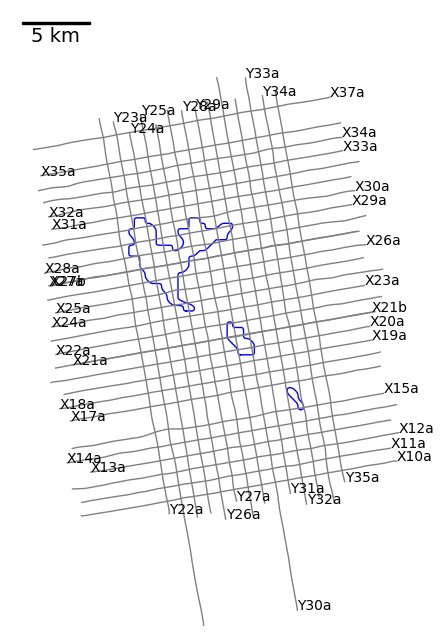

In [6]:
# Plot plan view comparison
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

plot_radargram_planview(ax, utig_radargrams, xs_lake, ys_lake)
scalebar = AnchoredSizeBar(ax.transData, 5000, '5 km', 'upper left', 
                           pad=0.5, color='black', frameon=False, size_vertical=200, fontproperties={'size': 14})
ax.add_artist(scalebar)


In [182]:
# Functions for calculating and interperting doppler spectra
def plot_hilbert_transform(radargram, data):
    vmin = -80
    vmax = 0

    eps = 1e-20
    amp = np.abs(data)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    im = ax.imshow(rad_db,aspect='auto',cmap='gray',vmin=vmin,vmax=vmax)

    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    ax.set_ylabel("Fast time [ns]",fontsize=16)
    ax.set_xlabel("Along Track Distance [m]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Relative Return [dB]", fontsize=16)

def compute_doppler_spectrum(radargram, data):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    start_y = 1200
    end_y = 1800
    start_x = 17500
    end_x = 18000

    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make freq axis
    t = utig_radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y

def compute_spectra_width(freq,data_fft,start_y,end_y):
    x = np.arange(len(data_fft))
    coeff = np.polyfit(x, data_fft, 2)

    # vertex of parabola
    x_peak = -coeff[1] / (2*coeff[0])
    y_peak = np.polyval(coeff, x_peak)

    return x, coeff


def plot_doppler_spectrum(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    print(rad_db)
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        vmin=-50, vmax=0
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Amplitude [dB]", fontsize=16)

    # Get x,y of max
    #x, y = np.unravel_index(np.argmax(rad_db, axis=None), rad_db.shape)
    #ax.scatter(freq[x], start_y + y, color='red', s=100, marker='x')

def plot_doppler_contourf(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    rad_db = gaussian_filter(rad_db, sigma=5)
    im = ax.contour(
        (rad_db),
        aspect='auto',
        cmap='viridis',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        vmin=-100, vmax=0,
        levels = 10
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Amplitude [dB]", fontsize=16)

def plot_doppler_edges(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    rad_db = gaussian_filter(rad_db, sigma=8)
    rad_db = feature.canny(rad_db, sigma=10)
    print(rad_db)
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        #vmin=-50, vmax=0
    )
    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Edge Probability", fontsize=16)

def plot_doppler_ridge(freq, data_fft, start_y, end_y):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    #rad_db = scipy.signal.medfilt2d(rad_db, kernel_size=11)
    #rad_db = gaussian_filter(rad_db, sigma=(1.0, 6.0))
    rad_db = gaussian_filter(rad_db, sigma=(3,2))
    rad_db = sato(rad_db, sigmas=range(10,15), black_ridges=False)
    mask = rad_db > (filters.threshold_otsu(rad_db) - 1)
    rad_db = rad_db * mask
    im = ax.imshow(
        (rad_db),
        aspect='auto',
        cmap='gray',
        origin='lower',
        extent = [freq[0], freq[-1],start_y, end_y],
        #vmin=-50, vmax=0
    )
    # Plot value of max rad_db for each column
    max_indices = np.argmax(rad_db, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db.shape[1])
    ax.scatter(x, start_y + max_indices, color='red', s=10, marker='x')


    ax.invert_yaxis()
    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    fig.tight_layout()
    ax.set_ylabel("Fast Time [ns]",fontsize=16)
    ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Sato [Thresholded]", fontsize=16)

    return x, start_y + max_indices,rad_db


In [161]:
utig_radargrams[16].transect_id

'D2DG/IBH0e/X26a'

In [168]:
radargram = utig_radargrams[16]
dat = radargram['bxds2'].compute().astype(np.float32) # bdxs2 is the low gain
# Hilbert along fast_time axis
analytic = hilbert(dat, axis=1)
data = analytic.T


In [169]:
freq, data_fft, start_y, end_y = compute_doppler_spectrum(utig_radargrams[0], data)

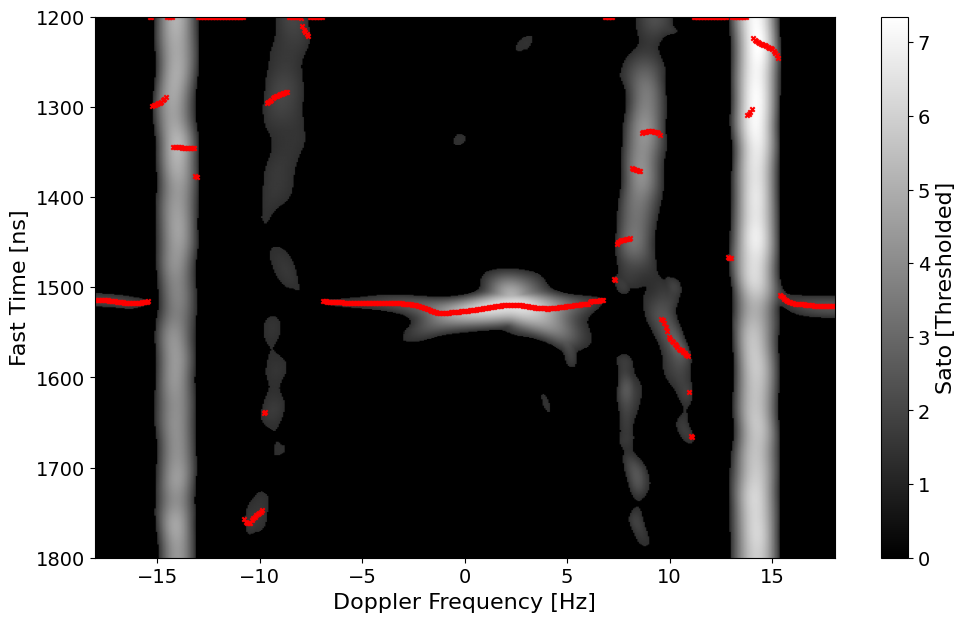

In [183]:
x_sato, y_sato, sobel_thresholded = plot_doppler_ridge(freq, data_fft, start_y, end_y)

[[-40.22539  -35.560764 -35.369377 ... -32.455284 -33.10072  -35.118294]
 [-40.69757  -37.376556 -37.64168  ... -34.12716  -33.939163 -35.413124]
 [-40.120506 -38.67084  -42.2539   ... -35.217377 -34.294888 -36.00025 ]
 ...
 [-43.852543 -47.856125 -43.192528 ... -35.44064  -39.49556  -36.94944 ]
 [-42.798904 -45.358032 -43.051983 ... -36.466915 -37.948692 -35.132565]
 [-42.323486 -44.273384 -43.481003 ... -38.126778 -38.047867 -34.000004]]


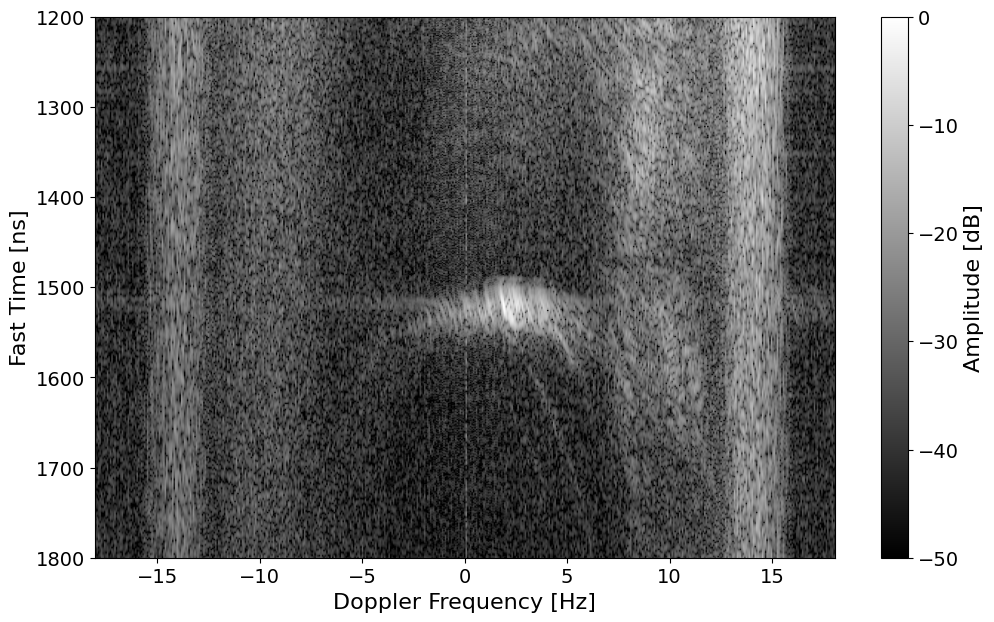

In [171]:
plot_doppler_spectrum(freq, data_fft, start_y, end_y)

/tmp/ipykernel_20837/989510328.py:100: UserWarning: The following kwargs were not used by contour: 'aspect'
  im = ax.contour(


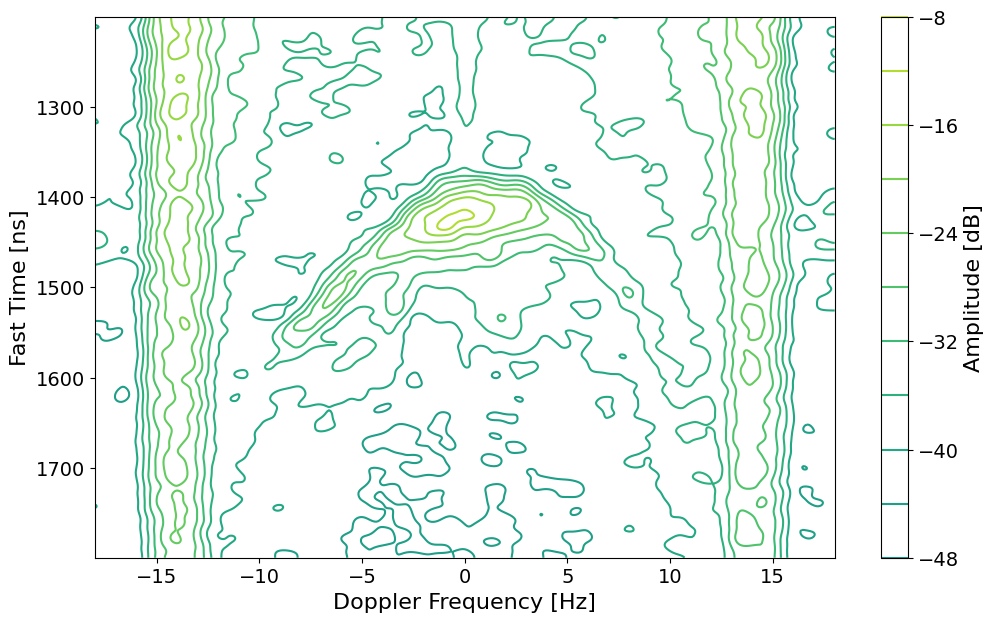

In [140]:
plot_doppler_contourf(freq, data_fft, start_y, end_y)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


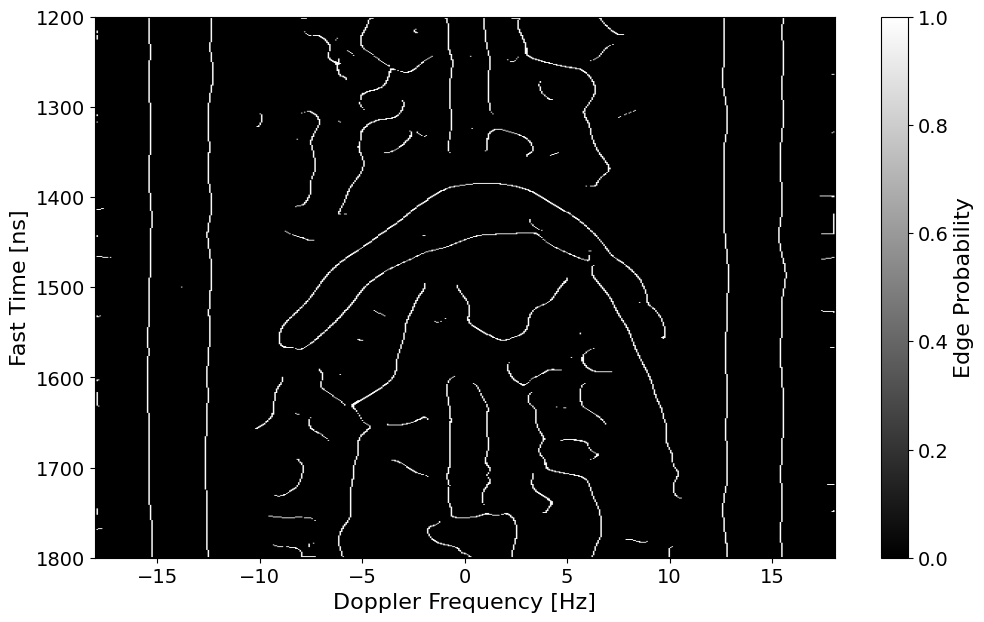

In [141]:
plot_doppler_edges(freq, data_fft, start_y, end_y)

In [180]:
# Find width and max
# Start with y location of middle point, assumed to be in the main parabola [valid unless severely sloping]
# Work out in both directions until distance between point and prior point > threshold
# Get delta_x between edges and find x value and maximum

def calc_width_and_max(x,y):
    y = -y # Flip direction
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Go forward
    threshold = 5  # ns
    diff = 0
    while diff < threshold:
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    # Go backward
    threshold = 5  # ns
    diff = 0
    while diff < threshold:
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    y_max = np.max(y_masked)
    x_at_max = x[np.argmax(y_masked) + left]

    width = x[right] - x[left]

    return width, x_at_max

width, x_at_max = calc_width_and_max(x_sato, y_sato)

print(f"Width: {width} Hz, Max Frequency: {x_at_max} Hz")

Width: 13.672976791957627 Hz, Max Frequency: 6.619457018328692 Hz


In [177]:
x_sato[343]

np.float64(6.764144603428772)

In [15]:
def plot_radargram_xsect(ax, analytic, vmin, vmax):
    # Scale to dB
    eps = 1e-20
    amp = np.abs(analytic)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)
    print(np.min(rad_db), np.max(rad_db))
    im = ax.imshow(rad_db.T,aspect='auto',cmap='gray',vmin=vmin,vmax=vmax)

    cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
    ax.set_ylabel("Fast time [ns]",fontsize=16)
    ax.set_xlabel("Along Track Distance [m]",fontsize=16)
    ax.tick_params(labelsize=14)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Relative Return [dB]", fontsize=16)

(200, 1000)
(800, 5000)


/tmp/ipykernel_1965/625776242.py:39: UserWarning: Adding colorbar to a different Figure <Figure size 2000x600 with 4 Axes> than <Figure size 1000x600 with 2 Axes> which fig.colorbar is called on.
  cb = fig.colorbar(im1, ax=ax, label="Relative Return [dB]")


"\nax.vlines(12000, 1450, 1650, colors='red', linestyles='-')\nax.vlines(14000, 1450, 1650, colors='red', linestyles='-')\nax.hlines(1450, 12000, 14000, colors='red', linestyles='-')\nax.hlines(1650, 12000, 14000, colors='red', linestyles='-')\n\nax.vlines(15000, 1450, 1650, colors='orange', linestyles='-')\nax.vlines(17000, 1450, 1650, colors='orange', linestyles='-')\nax.hlines(1450, 15000, 17000, colors='orange', linestyles='-')\nax.hlines(1650, 15000, 17000, colors='orange', linestyles='-')\n"

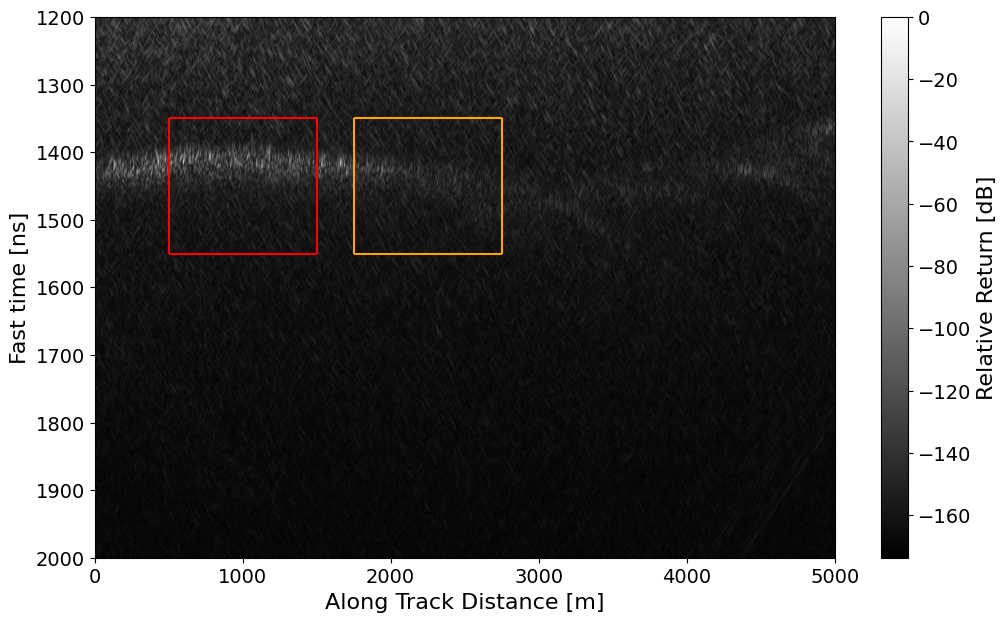

In [144]:
# Transform into doppler spectra
# x,y = [Length, Time] -> [Length, Frequency]

# Just take the portion with the bed, cut to 500 to 1000 in y, and 2000 to 10000 in x
data = analytic.T

start_y = 1200
end_y = 2000
start_x = 0
end_x = 5000

start_y_i1 = 1350
end_y_i1 = 1550
start_x_i1 = 500
end_x_i1 = 1500

start_y_i2 = 1350
end_y_i2 = 1550
start_x_i2 = 1750
end_x_i2 = 2750

data_for_plot = data[start_y:end_y:,start_x:end_x]
data_for_fft = data[start_y_i1:end_y_i1:,start_x_i1:end_x_i1]
print(data_for_fft.shape)
data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
print(data.shape)
data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)
# Make freq axis
t = utig_radargram['time'] 
t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
dt_slow = np.median(np.diff(t_sec.compute()))
n_slow = data.shape[1]
freq = np.fft.fftshift(
    np.fft.fftfreq(n_slow, d=dt_slow)
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(np.abs(data), aspect='auto', cmap='gray',extent=[start_x, end_x, end_y, start_y])
cb = fig.colorbar(im1, ax=ax, label="Relative Return [dB]")
fig.tight_layout()
ax.set_ylabel("Fast time [ns]",fontsize=16)
ax.set_xlabel("Along Track Distance [m]",fontsize=16)
ax.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
cb.set_label("Relative Return [dB]", fontsize=16)

# Box around center ofstart_y = 1200end_y = 2000start_x = 10000end_x = 20000

ax.vlines(start_x_i1, start_y_i1, end_y_i1, colors='red', linestyles='-')
ax.vlines(end_x_i1, start_y_i1, end_y_i1, colors='red', linestyles='-')
ax.hlines(start_y_i1, start_x_i1, end_x_i1, colors='red', linestyles='-')
ax.hlines(end_y_i1, start_x_i1, end_x_i1, colors='red', linestyles='-')

ax.vlines(start_x_i2, start_y_i2, end_y_i2, colors='orange', linestyles='-')
ax.vlines(end_x_i2, start_y_i2, end_y_i2, colors='orange', linestyles='-')
ax.hlines(start_y_i2, start_x_i2, end_x_i2, colors='orange', linestyles='-')
ax.hlines(end_y_i2, start_x_i2, end_x_i2, colors='orange', linestyles='-')

"""
ax.vlines(12000, 1450, 1650, colors='red', linestyles='-')
ax.vlines(14000, 1450, 1650, colors='red', linestyles='-')
ax.hlines(1450, 12000, 14000, colors='red', linestyles='-')
ax.hlines(1650, 12000, 14000, colors='red', linestyles='-')

ax.vlines(15000, 1450, 1650, colors='orange', linestyles='-')
ax.vlines(17000, 1450, 1650, colors='orange', linestyles='-')
ax.hlines(1450, 15000, 17000, colors='orange', linestyles='-')
ax.hlines(1650, 15000, 17000, colors='orange', linestyles='-')
"""

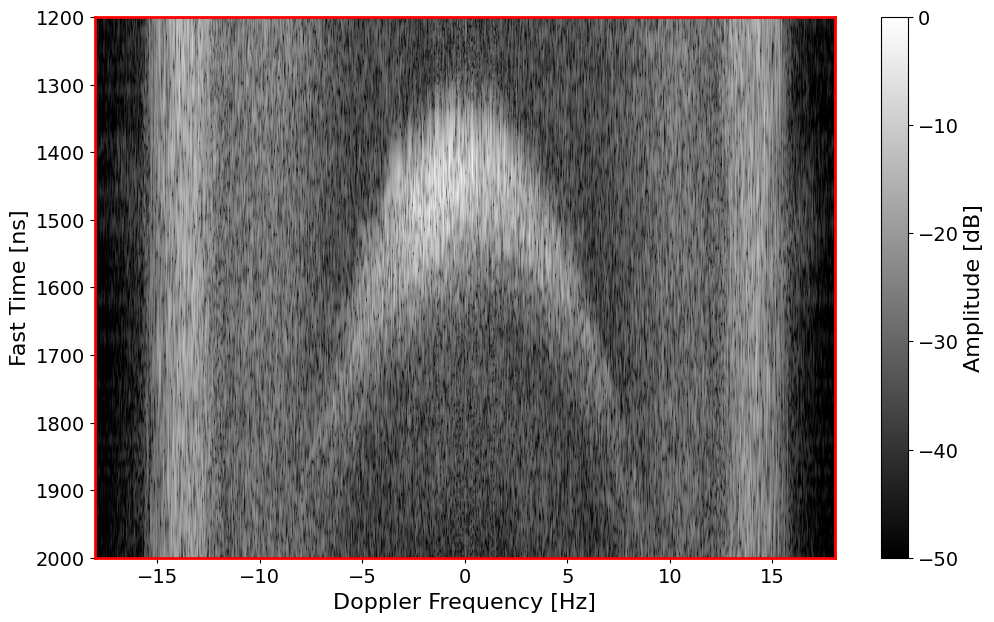

In [145]:
# Plot real part of fourier transformed data [i.e, doppler spectra] 
# Plot in dB

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

eps = 1e-20
amp = np.abs(data_fft)  
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)
im = ax.imshow(
    (rad_db),
    aspect='auto',
    cmap='gray',
    origin='lower',
    extent = [ freq[0], freq[-1],start_y, end_y],
    vmin=-50, vmax=0
)
ax.invert_yaxis()
cb = fig.colorbar(im, ax=ax, label="Amplitude [dB]")
fig.tight_layout()
ax.set_ylabel("Fast Time [ns]",fontsize=16)
ax.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
ax.tick_params(labelsize=14)
cb.ax.tick_params(labelsize=14)
cb.set_label("Amplitude [dB]", fontsize=16)

# Red axes border
for spine in ax.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(2)

In [153]:
x_at = utig_radargram['distance'].compute().values  # meters
dx = np.median(np.diff(x_at))
print("Along-track spacing:", dx, "m")

win_m = 1000.0     # window length [m]
ovlp_m = 500.0     # overlap [m]
win_n = int(win_m / dx)
step_n = int((win_m - ovlp_m) / dx)
print("Window samples:", win_n)
print("Step samples:", step_n)

dt_slow = np.median(np.diff(
    (utig_radargram['time'] - utig_radargram['time'][0])
    .astype('timedelta64[ns]')
    .astype(np.float64)
    .compute()
)) * 1e-9

freq = np.fft.fftshift(
    np.fft.fftfreq(win_n, d=dt_slow)
)


Along-track spacing: 1.0 m
Window samples: 1000
Step samples: 500


In [119]:
x_at

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 2.2226e+04, 2.2227e+04,
       2.2228e+04], shape=(22229,))

In [154]:
from scipy.signal.windows import hann
data = analytic.T
start_y = 1200
end_y = 1800
start_x = 10000
end_x = 22500

start_y = 1200
end_y = 2000
start_x = 0
end_x = 10000


data_for_plot = data[start_y:end_y:,start_x:end_x]
x_at = utig_radargram['distance'].compute().values  # meters
x_at = x_at[start_x:end_x]
data = data_for_plot - np.mean(data_for_plot, axis=0, keepdims=True)
window = hann(win_n)

doppler_cubes = []     # list of [range, doppler]
x_centers = []         # along-track center positions

for start in range(0, data.shape[1] - win_n + 1, step_n):
    stop = start + win_n

    # Extract slow-time window
    data_win = data[:, start:stop]

    # Apply slow-time window
    data_win = data_win * window[None, :]

    # Doppler FFT
    fft_win = np.fft.fftshift(
        np.fft.fft(data_win, axis=1),
        axes=1
    )

    doppler_cubes.append(fft_win)

    # Store center along-track distance
    x_centers.append(np.mean(x_at[start:stop]))


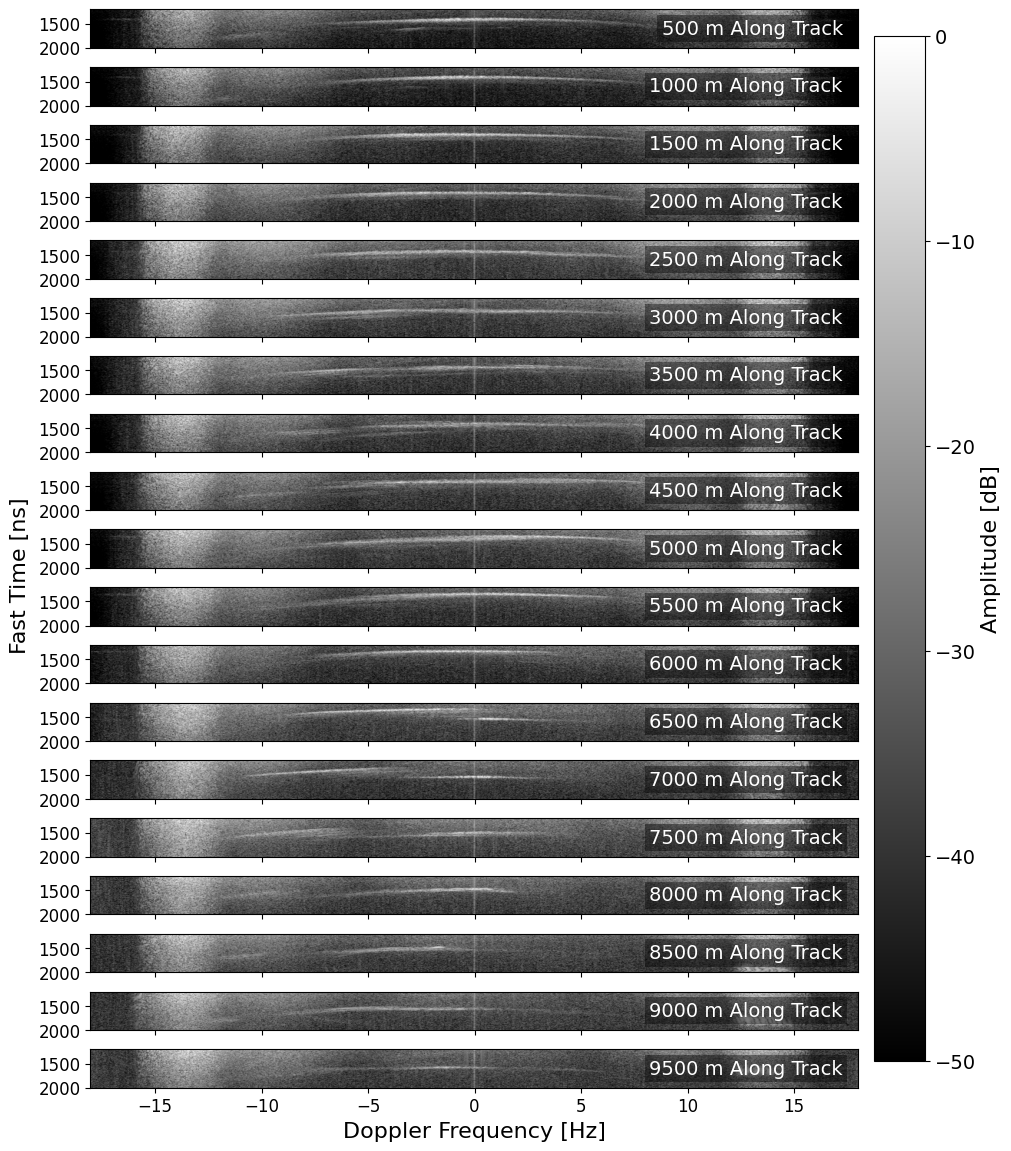

In [155]:
eps = 1e-20
doppler_db = []
for cube in doppler_cubes:
    amp = np.abs(cube)  
    amp = amp / np.max(amp)
    db = 20 * np.log10(amp + eps)
    doppler_db.append(db)

n = len(doppler_db)


fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(10, 0.6 * n),
    sharex=True,
    constrained_layout=True,
    gridspec_kw=dict(hspace=-0.5)
)

# Make axes iterable if n == 1
if n == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im = ax.imshow(
        doppler_db[i],
        aspect='auto',
        origin='lower',
        extent = [ freq[0], freq[-1],start_y, end_y],
        cmap='gray',
        vmin=-50, vmax=0
    )

    ax.invert_yaxis()
    #ax.set_ylabel("Fast Time [ns]", fontsize=14)
    ax.tick_params(labelsize=12)

    # Top-right panel title
    ax.text(
        0.98, 0.5,
        f"{x_centers[i]:.0f} m Along Track",
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=14,
        color="white",
        bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=3)
    )

# X label only on bottom panel
axes[-1].set_xlabel("Doppler Frequency [Hz]", fontsize=16)

# Single shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    pad=0.02,
    shrink=0.95
)
cbar.set_label("Amplitude [dB]", fontsize=16)
cbar.ax.tick_params(labelsize=14)
fig.supylabel("Fast Time [ns]", fontsize=16)

plt.show()


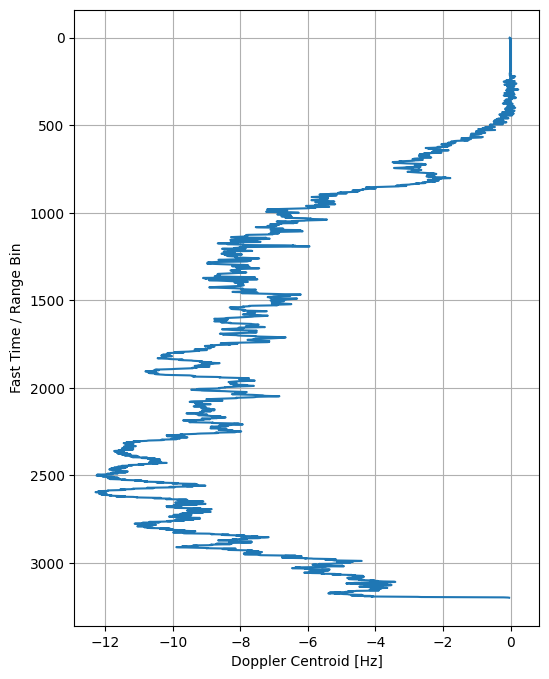

In [ ]:
# GPT Interpertation - Look at zero-Doppler reference by examining Doppler centroid as function of range
power = np.abs(data_fft)**2

doppler_centroid = (
    np.sum(freq[None, :] * power, axis=1) /
    np.sum(power, axis=1)
)

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(doppler_centroid, np.arange(data.shape[0]))
ax.invert_yaxis()
ax.set_xlabel("Doppler Centroid [Hz]")
ax.set_ylabel("Fast Time / Range Bin")
ax.grid()
plt.show()

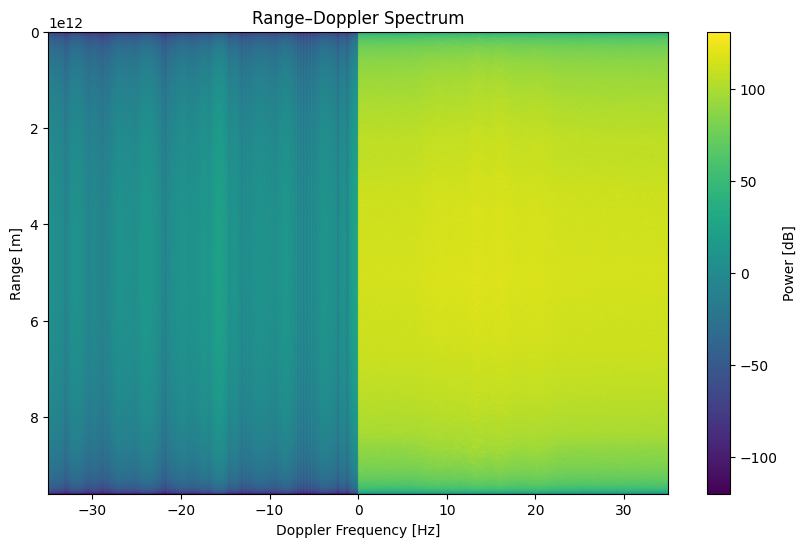

In [ ]:
# meters
dx = float(analytic_xr.distance.diff("distance").median())

# m/s (example – replace with real value)
platform_velocity = 70.0

dt_slow = dx / platform_velocity

# Remove slow-time mean (clutter suppression)
analytic_demean = analytic_xr - analytic_xr.mean("distance")

# Window in slow time
window = xr.DataArray(
    np.hanning(analytic_xr.sizes["distance"]),
    dims="distance",
    coords={"distance": analytic_xr.distance},
)

analytic_win = analytic_demean * window

RD = xr.apply_ufunc(
    np.fft.fft,
    analytic_win,
    input_core_dims=[["distance"]],
    output_core_dims=[["doppler"]],
    kwargs={"axis": 0},
)

RD = xr.apply_ufunc(
    np.fft.fftshift,
    RD,
    input_core_dims=[["doppler"]],
    output_core_dims=[["doppler"]],
    kwargs={"axes": 0},
)

RD_power = np.abs(RD) ** 2

Nd = analytic_xr.sizes["distance"]

doppler_freq = np.fft.fftshift(
    np.fft.fftfreq(Nd, d=dt_slow)
)

RD_power = RD_power.assign_coords(
    doppler=("doppler", doppler_freq)
)

c = 3e8  # or ice velocity if already converted
range_m = (analytic_xr.fast_time * c / 2).data

RD_power = RD_power.assign_coords(
    range=("fast_time", range_m)
)

plt.figure(figsize=(10, 6))

img = RD_power.T.data
img = 10 * np.log10(img + 1e-12)

plt.imshow(
    img,
    aspect="auto",
    extent=[
        float(RD_power.doppler.min()),
        float(RD_power.doppler.max()),
        float(RD_power.range.max()),
        float(RD_power.range.min()),
    ],
)

plt.xlabel("Doppler Frequency [Hz]")
plt.ylabel("Range [m]")
plt.colorbar(label="Power [dB]")
plt.title("Range–Doppler Spectrum")
plt.show()


In [ ]:
analytic_xr = xr.DataArray(
    analytic,
    dims=("distance", "fast_time"),
    coords={
        "distance": utig_radargram.distance,
        "fast_time": utig_radargram.fast_time
    }
)

z = analytic_xr - analytic_xr.mean(axis=0, keepdims=True)

w = np.hanning(z.shape[0])[:, None]
z_win = z * w
RD = np.fft.fftshift(
    np.fft.fft(z_win, axis=0),
    axes=0
)
v = 200.0        # m/s (use real HeRa velocity)
dx = 1.0         # m slow-time spacing

fs = v / dx
f_d = np.fft.fftshift(np.fft.fftfreq(RD.shape[0], d=1/fs))

RD_db = 20 * np.log10(np.abs(RD) + 1e-6)

plt.figure(figsize=(9, 6))
plt.imshow(
    RD_db.T,           # transpose so fast time is vertical
    aspect='auto',
    cmap='inferno',
    extent=[
        f_d[0], f_d[-1],
        analytic_xr.fast_time[-1], analytic_xr.fast_time[0]
    ]
)
plt.xlabel("Doppler frequency (Hz)")
plt.ylabel("Fast time (range)")
plt.title("Range–Doppler Map")
plt.colorbar(label="Power (dB)")
plt.show()

"""
z_r = analytic_xr[:, 1000:2000].mean(axis=0)
z_r = z_r - np.mean(z_r)
w = np.hanning(z_r.size)
z_r = z_r * w
doppler = np.fft.fftshift(
    np.fft.fft(z_r, axis=0)
)
plt.plot(20*np.log10(np.abs(doppler)+1e-6))
#z_r = analytic_xr.isel(fast_time=300)
#z_r = z_r - z_r.mean('distance')
#doppler = np.fft.fftshift(np.fft.fft(z_r))
#plt.plot(20*np.log10(np.abs(doppler)+1e-6))
"""

AlignmentError: cannot reindex or align along dimension 'distance' because of conflicting dimension sizes: {1, 15204} (note: an index is found along that dimension with size=15204)

Text(0, 0.5, 'Fast Time [usec?]')

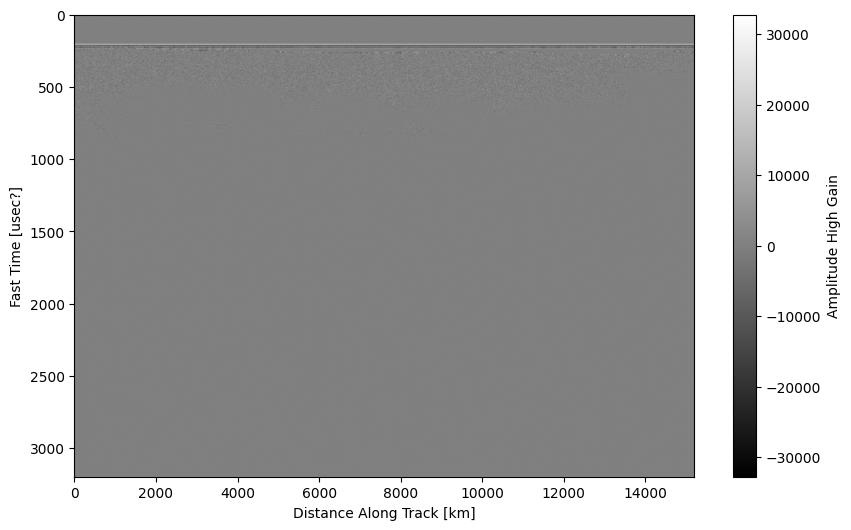

In [ ]:
# Plot utig radargram
fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(utig_radargram['bxds1'].T, aspect='auto', cmap='gray')
fig.colorbar(im, ax=ax, label='Amplitude High Gain')
ax.set_xlabel('Distance Along Track [km]')
ax.set_ylabel('Fast Time [usec?]')


In [ ]:
utig_radargram['fasttime'][].values

array([0, 0, 0, ..., 0, 0, 0], shape=(10926,), dtype='timedelta64[ns]')

In [ ]:
# Load basemap stuff
# Get new RINGS Gl
rings_grounded_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_coastline_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp'
rings_grounded_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_iceshelves_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp'
rings_islands_ADD = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp'
rings_polygonmask = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp'

paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax ,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(records_list, shapes_list, field_names_list):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(len(points)) # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                    part = points[parts[i] : parts[i + 1]]
                    if classification == "Coastline":
                        if fill:
                            ax.fill(*zip(*part), color=colors[1], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[1], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Grounded":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Transient":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Island":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    else:
                        #print(f"Unknown classification: {classification}")
                        pass


#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
#                    transform=ps71_projection, fill=True, zorder=2, linewidth=1)

#plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
#                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)


In [ ]:
#to_plot = radargrams_16_17[30:31][0][0]
#dir(to_plot)
for rad in radargrams_18_19[:]:
    to_plot = rad[0]
    print(to_plot.x_coord/10)

[67823.969 67823.271 67822.585 ... 65525.057 65523.879 65522.346]
[67778.369 67777.397 67776.359 ... 65528.833 65528.528 65528.521]
[67842.348 67841.536 67840.724 ... 65465.963 65465.776 65464.962]
[65590.    65591.04  65592.088 ... 67776.142 67776.579 67776.788]
[65414.017 65414.837 65415.648 ... 67816.869 67817.76  67818.683]
[67726.714 67725.833 67724.97  ... 65458.821 65457.896 65456.967]
[67731.472 67731.54  67731.49  ... 65377.495 65376.622 65375.764]
[65441.337 65442.14  65442.951 ... 67701.749 67702.613 67703.455]
[65363.226 65364.001 65364.77  ... 67700.813 67701.595 67702.365]
[67644.366 67643.329 67642.31  ... 65399.264 65398.479 65397.675]
[67625.207 67624.441 67623.706 ... 65302.852 65302.065 65301.274]
[65455.517 65456.552 65457.588 ... 67662.852 67663.806 67664.783]
[67642.435 67641.457 67640.478 ... 65335.955 65335.495 65335.262]
[65332.527 65333.437 65334.33  ... 67710.75  67711.62  67712.374]
[67588.272 67587.323 67586.363 ... 65304.511 65303.549 65302.599]
[65305.294

In [ ]:
# Load Lake Cheongsuk shapefile
sld_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/_Semesters/25FA/KOPRI/SLD2'
pathA = sld_path + '/SLD2-A.shp'
pathB = sld_path + '/SLD2-B.shp'
pathC = sld_path + '/SLD2-C.shp'

xs = []
ys = []
for path in [pathA, pathB, pathC]:
    sf = shapefile.Reader(path)
    shapes = sf.shapes()
    for shp in shapes:
        points = shp.points
        x = [p[0] for p in points]
        y = [p[1] for p in points]
    xs.append(x)
    ys.append(y)


In [ ]:
from pyproj import CRS, Transformer
def xy2ll(x: list[float], y: list[float]) -> tuple[list[float], list[float]]:
    """
    Transform coordinates from Antarctic Polar Stereographic coordinates (x, y)
    to output geodetic coordinates (lon, lat).
    Can also take single floats.

    Parameters
    ----------
    x: list[float]
       Antarctic Polar Stereographic (EPSG:3031) x
    y: list[float]
       Antarctic Polar Stereographic (EPSG:3031) y

    Returns
    -------
    lon: list[float]
         Geodetic longitude in EPSG:4326
    lat: list[float]
         Geodetic latitude in EPSG:4326
    """
    crs_ll = CRS("EPSG:4326")
    crs_xy = CRS("EPSG:3031")
    xy_to_ll = Transformer.from_crs(crs_xy, crs_ll, always_xy=True)
    lon, lat = xy_to_ll.transform(x, y)
    return lon, lat

In [ ]:
lon, lat = xy2ll(xs[0][0], ys[0][0])
print(lon, lat)

155.46287226044208 -75.38631843716142


[678239.69 678232.71 678225.85 ... 655250.57 655238.79 655223.46]
[677783.69 677773.97 677763.59 ... 655288.33 655285.28 655285.21]
[678423.48 678415.36 678407.24 ... 654659.63 654657.76 654649.62]
[655900.   655910.4  655920.88 ... 677761.42 677765.79 677767.88]
[654140.17 654148.37 654156.48 ... 678168.69 678177.6  678186.83]
[677267.14 677258.33 677249.7  ... 654588.21 654578.96 654569.67]
[677314.72 677315.4  677314.9  ... 653774.95 653766.22 653757.64]
[654413.37 654421.4  654429.51 ... 677017.49 677026.13 677034.55]
[653632.26 653640.01 653647.7  ... 677008.13 677015.95 677023.65]
[676443.66 676433.29 676423.1  ... 653992.64 653984.79 653976.75]
[676252.07 676244.41 676237.06 ... 653028.52 653020.65 653012.74]
[654555.17 654565.52 654575.88 ... 676628.52 676638.06 676647.83]
[676424.35 676414.57 676404.78 ... 653359.55 653354.95 653352.62]
[653325.27 653334.37 653343.3  ... 677107.5  677116.2  677123.74]
[675882.72 675873.23 675863.63 ... 653045.11 653035.49 653025.99]
[653052.94

(-1605000.0, -1320000.0)

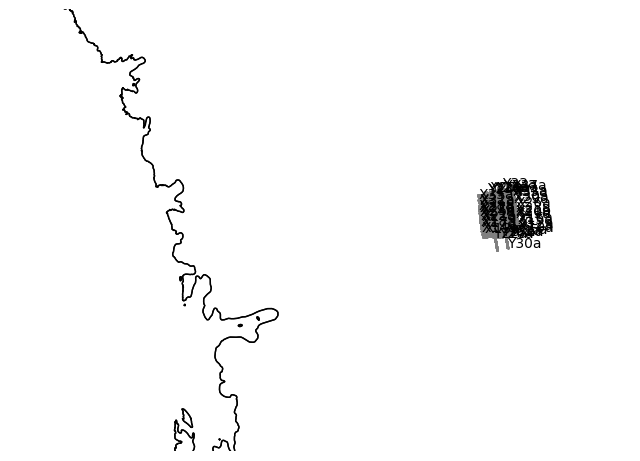

In [ ]:
# Make map showing names of each radargram
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': ps71_projection})

bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full
names = [path.split('/')[-1].split('.')[0] for path in file_paths_18_19]


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax.patch.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

for radargram in radargrams_18_19[:]:
    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.1, color='gray', zorder=3)
    ax.text(radargram[0].x_coord[0]*1, radargram[0].y_coord[0]*1, names[radargrams_18_19.index(radargram)], color='black', fontsize=10, transform=ps71_projection, zorder=4)

for x, y in zip(xs, ys):
    ax.plot(x, y, color='blue', linewidth=1.5)

ax.set_xlim(bbox[0],bbox[2])
ax.set_ylim(bbox[1],bbox[3])

    

In [ ]:
# Choose radargram and get along track distance
# Get radargram at index of 'XXX' in names
to_plot = radargrams_18_19[names.index('X19a')][0]
x_start = to_plot.x_coord[0]
y_start = to_plot.y_coord[0]
dist_along_track = np.sqrt((to_plot.x_coord/10 - x_start)**2 + (to_plot.y_coord/10 - y_start)**2)

(-1605000.0, -1320000.0)

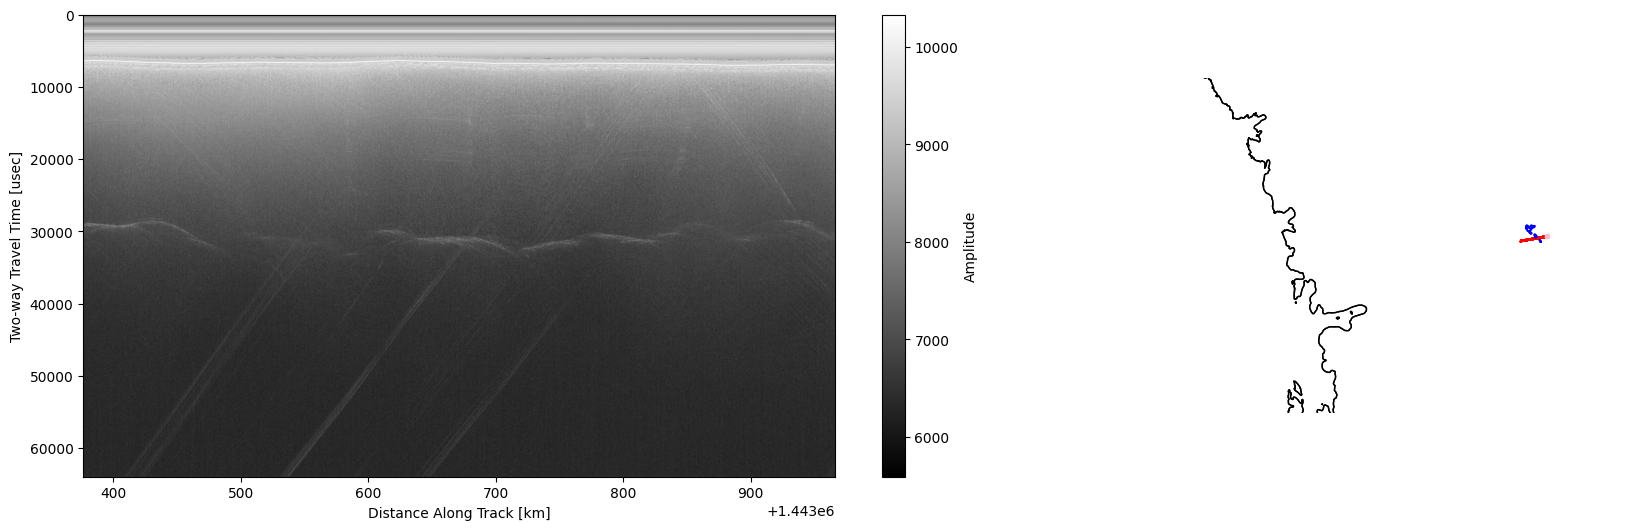

In [ ]:
# Plot two panel plot of radargram and position in map of Antarctica
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], projection=ps71_projection)

### AX1 ###

im = ax1.imshow(to_plot.data, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], to_plot.travel_time[-1], to_plot.travel_time[0]])
fig.colorbar(im, ax=ax1, label='Amplitude')
ax1.set_xlabel('Distance Along Track [km]')
ax1.set_ylabel('Two-way Travel Time [usec]')




### AX2 ###
bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax2, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax2.patch.set_facecolor("none")
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])


for radargram in radargrams_18_19[:]:
    ax.scatter(radargram[0].x_coord*1, radargram[0].y_coord*1, s=0.1, color='gray', zorder=3)


ax2.scatter(to_plot.x_coord, to_plot.y_coord, s=0.1, color='red', transform=ps71_projection, zorder=4)
ax2.scatter(to_plot.x_coord[0], to_plot.y_coord[0], s=10, color='pink', transform=ps71_projection, zorder=5)


for x, y in zip(xs, ys):
    ax2.plot(x, y, color='blue', linewidth=1.5, zorder=6)

ax2.set_xlim(bbox[0],bbox[2])
ax2.set_ylim(bbox[1],bbox[3])


In [ ]:
to_plot.data.shape

(3200, 2692)

In [ ]:
# Choose radargram and get along track distance
# Get radargram at index of 'XXX' in names
to_plot = radargrams_16_17[names.index('GL0328c')][0]
x_start = to_plot.x_coord[0]/10
y_start = to_plot.y_coord[0]/10
dist_along_track = np.sqrt((to_plot.x_coord/10 - x_start)**2 + (to_plot.y_coord/10 - y_start)**2)

NameError: name 'names' is not defined

In [ ]:
print(type(radargrams_16_17_Ju[0][0].data[0][0]))

<class 'numpy.float32'>


(-1605000.0, -1320000.0)

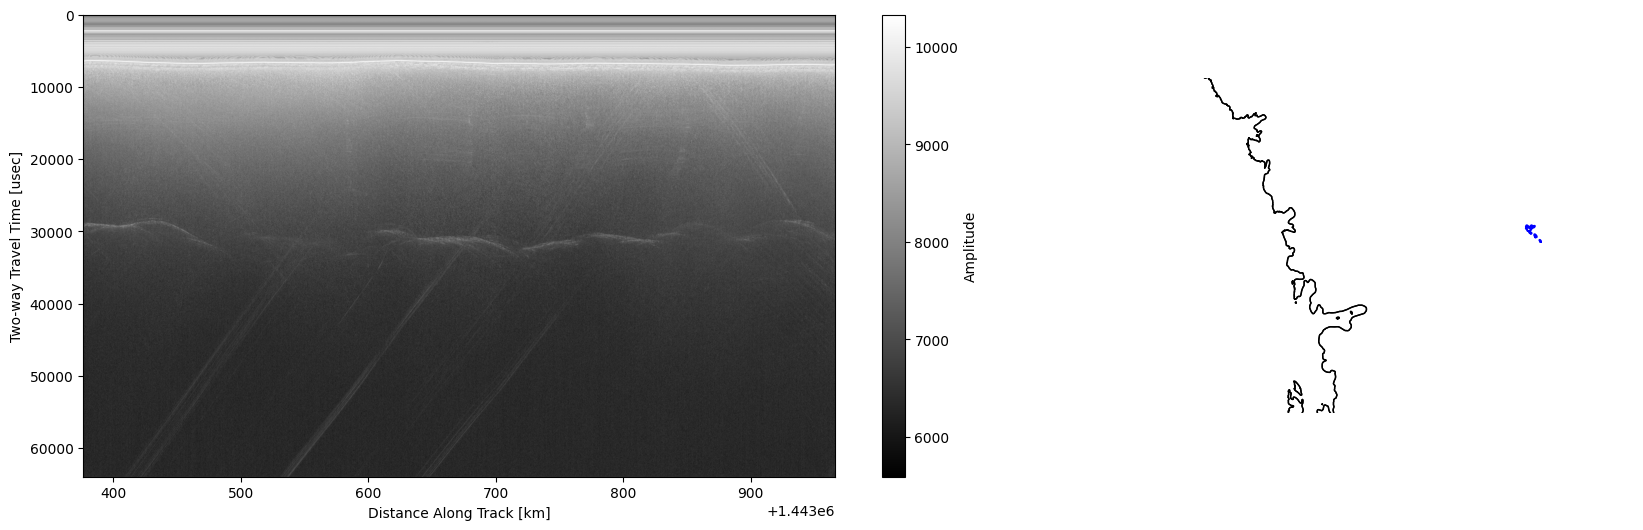

In [ ]:
# Plot two panel plot of radargram and position in map of Antarctica
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], projection=ps71_projection)

### AX1 ###

im = ax1.imshow(to_plot.data, aspect='auto', cmap='gray', extent=[dist_along_track[0], dist_along_track[-1], to_plot.travel_time[-1], to_plot.travel_time[0]])
fig.colorbar(im, ax=ax1, label='Amplitude')
ax1.set_xlabel('Distance Along Track [km]')
ax1.set_ylabel('Two-way Travel Time [usec]')




### AX2 ###
bbox = [350000,-1605000,750000,-1320000] #David_SGL2_full


plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax2, colors=['black','None'],
                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

ax2.patch.set_facecolor("none")
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.set_xticks([])
ax2.set_yticks([])

for radargram in radargrams_16_17:
    ax2.scatter(radargram[0].x_coord*100, radargram[0].y_coord*100, s=0.1, color='gray', transform=ps71_projection, zorder=3)

ax2.scatter(to_plot.x_coord*100, to_plot.y_coord*100, s=0.1, color='red', transform=ps71_projection, zorder=4)
ax2.scatter(to_plot.x_coord[0]*100, to_plot.y_coord[0]*100, s=10, color='pink', transform=ps71_projection, zorder=5)


for x, y in zip(xs, ys):
    ax2.plot(x, y, color='blue', linewidth=1.5, zorder=6)

ax2.set_xlim(bbox[0],bbox[2])
ax2.set_ylim(bbox[1],bbox[3])


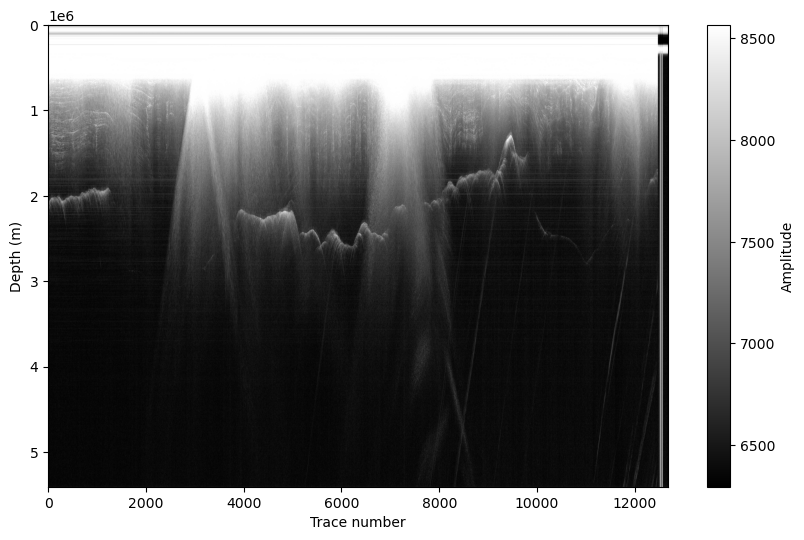

In [ ]:
test_rad_gram = radargrams_16_17[0][0]
fig, ax = plt.subplots(figsize=(10, 6))
im, xd, yd, x_range, clims = plot_radargram(test_rad_gram, ydat='depth', xdat='tnum', ax=ax, fig=fig, return_plotinfo=True)
fig.colorbar(im, ax=ax, label='Amplitude')

In [ ]:
print(dir(test_rad_gram))
test_rad_gram.chan
test_rad_gram.data.shape, test_rad_gram.data_dtype

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get_pick_targ_info', '_parse_stodeepdata', 'adaptivehfilt', 'agc', 'attrs_guaranteed', 'attrs_optional', 'chan', 'check_attrs', 'clean_GPS', 'constant_sample_depth_spacing', 'constant_space', 'crop', 'data', 'data_dtype', 'datetime', 'decday', 'denoise', 'dist', 'dt', 'elev', 'elev_correct', 'flags', 'fn', 'get_ll', 'get_projected_coords', 'hcrop', 'hfilt', 'highpass', 'horizontal_band_pass', 'horizontalfilt', 'lat', 'long', 'lowpass', 'migrate', 'nmo', 'nmo_depth', 'output_csv', 'output_ogr', 'output_shp', 'picks', 'pressure', 'rangegain', 'restack', 'reverse', 'save', 'save_as_segy', 'snum', 'stodeep_attrs', 't_srs', 'tnum', 't

((3200, 12683), dtype('float32'))

(<Figure size 800x1200 with 1 Axes>,
 <Axes: xlabel='Amplitude', ylabel='Two way travel time (usec)'>)

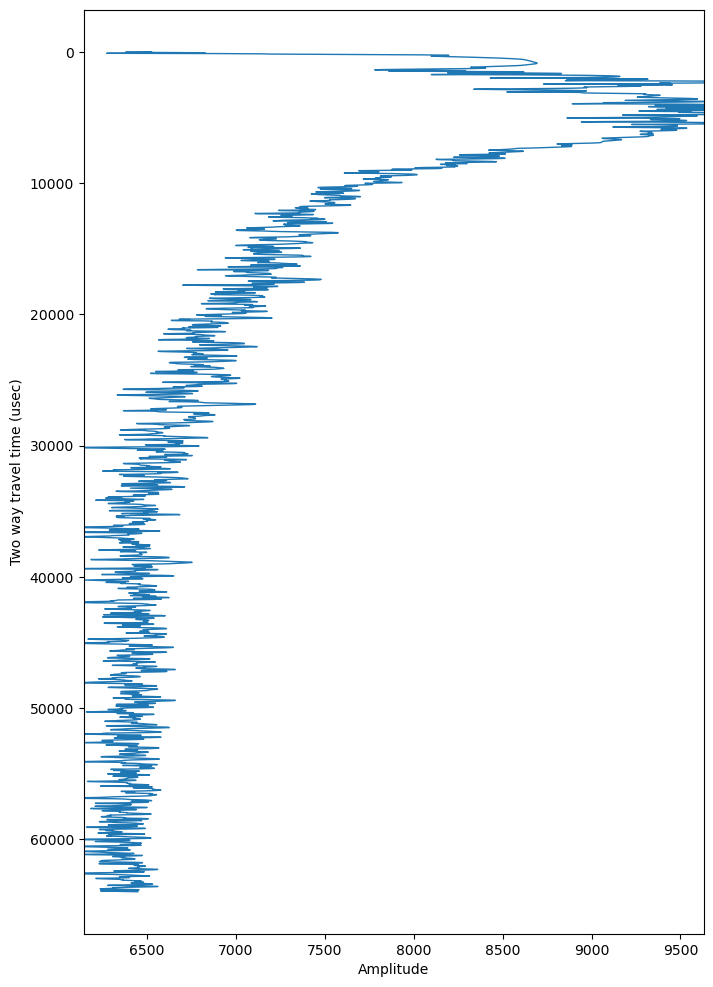

In [ ]:
# Plot trace
#test_rad_gram.vertical_band_pass(0.00001,0.01)
plot_traces(test_rad_gram,tr=100)

In [ ]:
#file_paths = [os.path.join('./_data/IPR_2016-2017', f) for f in os.listdir('./_data/IPR_2016-2017') if f.endswith('.segy')]
file_paths = [os.path.join('./_data/IPR_2018-2019', f) for f in os.listdir('./_data/IPR_2018-2019') if f.endswith('.segy')]
USEC_TO_SEC = 1e-6

In [ ]:
radargrams = [_read_segy(file_paths[i], unpack_trace_headers=True) for i in range(len(file_paths[12:13]))]


In [ ]:
print(rad.traces[0].stats.segy.trace_header.sample_interval_in_ms_for_this_trace)
print(USEC_TO_SEC)


20000

In [ ]:
for rad in radargrams[:1]:
    for tr in rad[:1].traces:
        print(tr.stats.segy)

AttribDict({'trace_header': AttribDict({'endian': '>', 'unpacked_header': None, 'trace_sequence_number_within_line': 1, 'trace_sequence_number_within_segy_file': 1, 'original_field_record_number': 1, 'trace_number_within_the_original_field_record': 1, 'energy_source_point_number': 1, 'ensemble_number': 1, 'trace_number_within_the_ensemble': 0, 'trace_identification_code': 0, 'number_of_vertically_summed_traces_yielding_this_trace': 1, 'number_of_horizontally_stacked_traces_yielding_this_trace': 1, 'data_use': 1, 'distance_from_center_of_the_source_point_to_the_center_of_the_receiver_group': 0, 'receiver_group_elevation': 182543, 'surface_elevation_at_source': 182543, 'source_depth_below_surface': 0, 'datum_elevation_at_receiver_group': 182543, 'datum_elevation_at_source': 182543, 'water_depth_at_source': 0, 'water_depth_at_group': 0, 'scalar_to_be_applied_to_all_elevations_and_depths': -100, 'scalar_to_be_applied_to_all_coordinates': -100, 'source_coordinate_x': 65414017, 'source_coord